# Photon Subtraction in Graph State
2026\. 05\. 19.  Make the pseudo code

## 1. Set the graph state

##### Initial parameters, modules and functions

In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
# Graph: paper-style 6-node graph, labels 1-6 1-2-(3,4)-5-6 graph
Adj = np.array([[0, 1, 0, 0, 0, 0],
                [1, 0, 1, 1, 0, 0],
                [0, 1, 0, 0, 1, 0],
                [0, 1, 0, 0, 1, 0],
                [0, 0, 1, 1, 0, 1],
                [0, 0, 0, 0, 1, 0]], dtype=float)
m = Adj.shape[0]

# Phase-space convention: q = (x1, ..., xm, p1, ..., pm)
I_m = np.eye(m)
Z_m = np.zeros((m, m))
Omega = np.block([[Z_m, I_m], [-I_m, Z_m]]) # [0, I; -I, 0] symplectic form
J = Omega.T # [0, -I; I, 0] symplectic form in Mattia's convention

# CZ symplectic matrix
G = np.block([[I_m, Z_m], [Adj, I_m]])

# Input covariance, paper convention: vacuum variance = 1
squeezing_db = np.full(m, 10, dtype=float) # 단위는 dB 
#squeezing_db = np.array([3, 4, 12, 5, 3, 5], dtype=float) # mode별로 squeezing 다르게 주는 경우

s = 10 ** (squeezing_db / 10) # 단위 변환
V0 = np.diag(np.concatenate([s, 1 / s])) # diag(s_1, ..., s_m, 1/s_1, ..., 1/s_m)


# Graph-state covariance
V = G @ V0 @ G.T # maybe later we adjust this code to general mixed case.

# Photon-subtraction mode
# annhilation operator 기준으로 photon subtraction을 설명하기 위한 f이다. 복소수가 가능하며 C^(m)이다.
# a(f) = f1 a1 + f2 a2 + ... + fm am 이다.

f_sub = np.array([1, 0, 0, 0, 0, 0], dtype=complex) # a(f_sub) = sum f_sub[i] a_i
f_sub = f_sub / np.linalg.norm(f_sub) # 정규화

# mattia convention으로 표현, g_sub이 전부 실수 R^(2m)이다. -> 이는 quadrature 기준으로 중첩을 설명하기 위한 convention이다.
# 수식적으로는 g = (Re(f), -Im(f))^T)이고, Q(g) = x(g), Q(Jg) = p(g)이다.

g_sub = np.concatenate([np.real(f_sub), -np.imag(f_sub)]) # g_sub = (Re(f_sub), -Im(f_sub)) in phase space , a(f_sub) = 1/2 (Q(g_sub)+iQ(Jg_sub)) 
Jg_sub = J @ g_sub
Pi_g = np.outer(g_sub, g_sub) + np.outer(Jg_sub, Jg_sub) # Πg =ggT + Jg(Jg)T , projection matrix for the subtracted mode

sub_label = "mode 1" # just label for the plot later

###### graph plotting function

In [48]:
from matplotlib.colors import LinearSegmentedColormap

blue = LinearSegmentedColormap.from_list(
    "blue",
    ["#3f5f87", "#7b8a70", "#fffbe6"]
)

red = LinearSegmentedColormap.from_list(
    "red",
    ["#18051f", "#5b2a86", "#d44a1c", "#ffc247", "#fffbe6"]
)

In [49]:
def plot_graph_from_matrix(
    W,
    node_values=None,
    title="",
    threshold=1e-6,
    pos=None,
    cmap=blue,
    vmin=None,
    vmax=None,
    colorbar_label="",
    draw_labels=None
):
    """
    W: weighted adjacency matrix 
    node_values: optional node color values, e.g. kurtosis, purity, nullifier_var
    """

    W_plot = np.array(W, dtype=float).copy()
    G_plot = nx.from_numpy_array(W_plot)

    # automatic layout - 어느정도 정렬된 그래프를 그려준다. 더 깔끔하게 그리고 싶을때는 pos를 직접 지정
    if pos is None:
        pos = nx.kamada_kawai_layout(G_plot)

    # node label을 1부터 시작하게 바꿈
    labels = {i: i + 1 for i in range(W_plot.shape[0])}

    # node_values가 있으면 논문 figure처럼 label을 기본적으로 끔
    if draw_labels is None:
        draw_labels = node_values is None

    # plotting // 사이즈 고정
    plt.figure(figsize=(4.2, 3.2), dpi=180)
    
    # graph edge(선) 그리기
    nx.draw_networkx_edges(
        G_plot,
        pos,
        edge_color="#5b668a",
        width=1.4,
        alpha=0.75
    )

    # graph node(노드) 그리기
    if node_values is None:
        nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color="white",
            edgecolors="black",
            linewidths=1.1,
            node_size=700
        )

    else:
        node_values_plot = np.asarray(node_values, dtype=float)

        # colorbar range를 node_values에서 자동 설정
        if vmin is None:
            vmin = np.nanmin(node_values_plot)
        if vmax is None:
            vmax = np.nanmax(node_values_plot)

        # 모든 node value가 같은 경우 colorbar error 방지
        if np.isclose(vmin, vmax):
            vmin -= 1e-9
            vmax += 1e-9

        nodes = nx.draw_networkx_nodes(
            G_plot,
            pos,
            node_color=node_values_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolors="#444444",
            linewidths=1.1,
            node_size=500
        )

        cbar = plt.colorbar(nodes, fraction=0.045, pad=0.03)
        if colorbar_label:
            cbar.set_label(colorbar_label, fontsize=9)
        cbar.ax.tick_params(labelsize=8)

    # graph label 그리기
    if draw_labels:
        nx.draw_networkx_labels(
            G_plot,
            pos,
            labels=labels,
            font_color="black",
            font_size=9
        )

    plt.title(title, fontsize=10, pad=6)
    plt.axis("equal")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    return pos

###### matrix visualization function

In [50]:
def show_mat(M, name="M", digits=3, tol=1e-10):
    M_show = np.array(M, dtype=float).copy()
    M_show[np.abs(M_show) < tol] = 0

    n, m = M_show.shape
    df = pd.DataFrame(
        M_show,
        index=[f"{i+1}" for i in range(n)],
        columns=[f"{j+1}" for j in range(m)]
    )

    print(name)
    display(df.style.format(f"{{:.{digits}f}}"))

In [51]:
def draw_mat(M, title="", cmap="bwr", label=False, digits=2, vlim=None, figsize=(4.5, 4)):
    M = np.asarray(M)
    n, m = M.shape

    vmax = np.percentile(np.abs(M), 95) if vlim is None else vlim
    vmax = vmax if vmax > 0 else 1

    fig, ax = plt.subplots(figsize=figsize, dpi=160)
    im = ax.imshow(
        M,
        cmap=cmap,
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
        aspect="equal"
    )

    ax.set_xticks(range(m), labels=range(1, m + 1))
    ax.set_yticks(range(n), labels=range(1, n + 1))
    ax.tick_params(
        top=True, labeltop=True,
        bottom=False, labelbottom=False,
        labelsize=8
    )

    if label:
        for i in range(n):
            for j in range(m):
                ax.text(
                    j, i, f"{M[i, j]:.{digits}f}",
                    ha="center", va="center", fontsize=6
                )

    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

##### Graph-State Sanity

In [52]:
print("m =", m)

print("Adj =\n", Adj)
print("V =\n", V)

print("f_sub =", f_sub)
print("f_sub shape =", f_sub.shape)

eigvals_physical = np.linalg.eigvalsh(V + 1j * Omega)
print("physical covariance(V + iOmega):", np.min(eigvals_physical) >= -1e-10)
#print("min eigenvalue of V + iOmega =", np.min(eigvals_physical))

m = 6
Adj =
 [[0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]
V =
 [[10.   0.   0.   0.   0.   0.   0.  10.   0.   0.   0.   0. ]
 [ 0.  10.   0.   0.   0.   0.  10.   0.  10.  10.   0.   0. ]
 [ 0.   0.  10.   0.   0.   0.   0.  10.   0.   0.  10.   0. ]
 [ 0.   0.   0.  10.   0.   0.   0.  10.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.  10.   0.   0.   0.  10.  10.   0.  10. ]
 [ 0.   0.   0.   0.   0.  10.   0.   0.   0.   0.  10.   0. ]
 [ 0.  10.   0.   0.   0.   0.  10.1  0.  10.  10.   0.   0. ]
 [10.   0.  10.  10.   0.   0.   0.  30.1  0.   0.  20.   0. ]
 [ 0.  10.   0.   0.  10.   0.  10.   0.  20.1 20.   0.  10. ]
 [ 0.  10.   0.   0.  10.   0.  10.   0.  20.  20.1  0.  10. ]
 [ 0.   0.  10.  10.   0.  10.   0.  20.   0.   0.  30.1  0. ]
 [ 0.   0.   0.   0.  10.   0.   0.   0.  10.  10.   0.  10.1]]
f_sub = [1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
f_sub shape = (6,)
physical covariance(V + iOm

chosen: p - Γx
nullifier variances = [0.1 0.1 0.1 0.1 0.1 0.1]
below vacuum: [ True  True  True  True  True  True]
Adj_eff =
 [[0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 1. 0. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 1. 0. 1.]
 [0. 0. 0. 0. 1. 0.]]


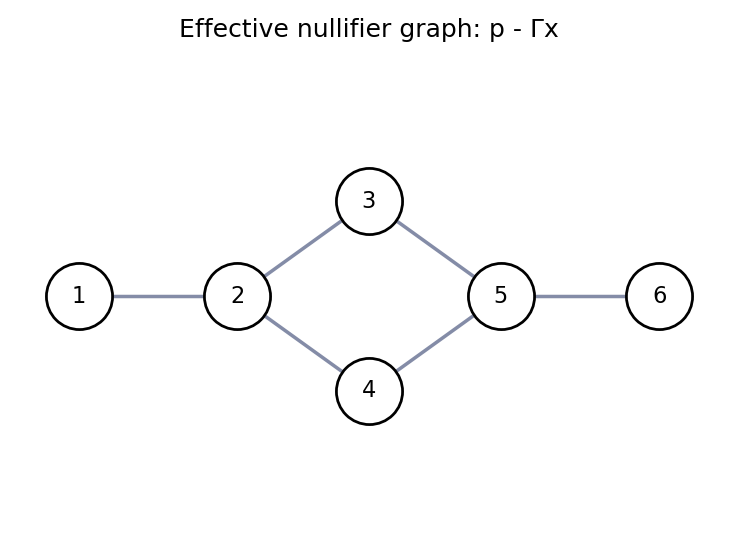

In [53]:
# Effective nullifier graph from V
V_xx = V[:m, :m]
V_xp = V[:m, m:]
V_px = V[m:, :m]
V_pp = V[m:, m:]

# nullfier 1 -> delta1 = p - Gamma1 x 꼴인 경우
Gamma1 = V_px @ np.linalg.pinv(V_xx)
Vd1 = V_pp - Gamma1 @ V_xp - V_px @ Gamma1.T + Gamma1 @ V_xx @ Gamma1.T


# nullfier 2 -> delta2 = x - Gamma2 p 꼴인 경우
Gamma2 = V_xp @ np.linalg.pinv(V_pp)
Vd2 = V_xx - Gamma2 @ V_px - V_xp @ Gamma2.T + Gamma2 @ V_pp @ Gamma2.T

# choose better nullifier
if np.trace(Vd1) <= np.trace(Vd2):
    Gamma_eff = Gamma1
    V_delta = Vd1
    nullifier_type = "p - Γx"
else:
    Gamma_eff = Gamma2
    V_delta = Vd2
    nullifier_type = "x - Γp"

nullifier_var = np.diag(V_delta)




print("chosen:", nullifier_type)
# nullifier variances 출력
print("nullifier variances =", nullifier_var)

# check nullifier variances below vacuum
print("below vacuum:", nullifier_var < 1)

# 해당 nullifer variances로 나온 effective adjacency matrix 출력
print("Adj_eff =\n", Gamma_eff)


# plot the graph using the graph plotting function defined above 
# plot_graph_from_matrix (W=Gamma_eff, node_values=kurtosis같은 노드별 값(기본은 none), title=f"(제목)", pos=pos(기본은 none))
pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=None,
    title=f"Effective nullifier graph: {nullifier_type}",
    pos=  
    {
    0: (0.0, 0.0),
    1: (1.5, 0.0),
    2: (2.75, 0.9),
    3: (2.75, -0.9),
    4: (4.0, 0.0),
    5: (5.5, 0.0),
    }
)

## 2. Photon Subtraction on the graph

##### A Matrix for Photon Subtraction

In [54]:
# A_minus matrix
# A_minus = 2 (V - I) Πg (V - I) / Tr[(V - I) Πg]

I_2m = np.eye(2 * m) # 2m x 2m identity matrix, m은 모드 수

denom = np.trace((V - I_2m) @ Pi_g) # 분모 계산, Tr[(V - I) Πg] , 이거의 4배값이 photon subtraction의 성공확률

# print("denom =", denom)
# 예외처리
if np.isclose(denom, 0):
    raise ValueError("denom is close to zero: photon subtraction mode may be vacuum-like.")

A_minus = 2 * (V - I_2m) @ Pi_g @ (V - I_2m) / denom

print("Pi_g projector check:", bool(np.linalg.norm(Pi_g @ Pi_g - Pi_g))<1e-10)
print("A_minus symmetric check:", bool(np.linalg.norm(A_minus - A_minus.T) < 1e-10))
#print("A_minus =\n", A_minus)
show_mat(A_minus, name="A_minus = ")
#draw_mat(A_minus, r"$A_g^-$")


Pi_g projector check: True
A_minus symmetric check: True
A_minus = 


,1,2,3,4,5,6,7,8,9,10,11,12
1,8.950,0.000,0.000,0.000,0.000,0.000,0.000,9.945,0.000,0.000,0.000,0.000
2,0.000,11.050,0.000,0.000,0.000,0.000,10.055,0.000,11.050,11.050,0.000,0.000
3,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,0.000,10.055,0.000,0.000,0.000,0.000,9.150,0.000,10.055,10.055,0.000,0.000
8,9.945,0.000,0.000,0.000,0.000,0.000,0.000,11.050,0.000,0.000,0.000,0.000
9,0.000,11.050,0.000,0.000,0.000,0.000,10.055,0.000,11.050,11.050,0.000,0.000
10,0.000,11.050,0.000,0.000,0.000,0.000,10.055,0.000,11.050,11.050,0.000,0.000


v_p = [10.1 30.1 20.1 20.1 30.1 10.1]
a_p = [ 9.15027624 11.04972376 11.04972376 11.04972376  0.          0.        ]
K_ex_p = [-0.67782211 -0.2163168  -0.37749891 -0.37749891 -0.         -0.        ]


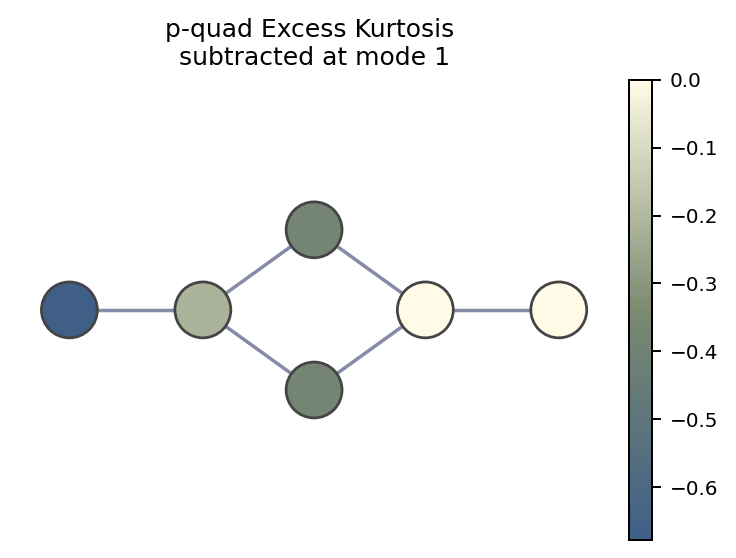

In [60]:
# Node-wise p-quadrature excess kurtosis

p_indices = np.arange(m, 2 * m) # p-quadrature는 phase space 벡터의 뒤쪽 m개 요소에 해당하므로, 인덱스가 m부터 2m-1까지인 부분을 선택

v_p = np.diag(V)[p_indices] # photon subtraction 전의 p-quadrature variance, V 행렬의 뒤쪽 m개 대각 원소에 해당
a_p = np.diag(A_minus)[p_indices] # photon subtraction으로 인한 p-quadrature variance 변화량, A_minus 행렬의 뒤쪽 m개 대각 원소에 해당

K_ex_p = -3 * (a_p ** 2) / ((v_p + a_p) ** 2) # <Q(f)^k>_T를 통해 excess kurtosis p-quadrature 계산, 

print("v_p =", v_p)
print("a_p =", a_p)
print("K_ex_p =", K_ex_p)

pos = plot_graph_from_matrix(
    Gamma_eff,
    node_values=K_ex_p,
    title=f"p-quad Excess Kurtosis \nsubtracted at {sub_label}",
    pos=pos,
    draw_labels=False
)
